In [4]:
import numpy as np

def binomial_tree(S, K, T, r, sigma, N, option_type='call', american=False):
    """
    Cox-Ross-Rubinstein binomial tree option pricer.
    
    Parameters:
        S     : spot price
        K     : strike price
        T     : time to expiry in years
        r     : risk-free rate (annualized)
        sigma : volatility (annualized)
        N     : number of time steps
        option_type: 'call' or 'put'
        american: True for American option (early exercise allowed)
    
    Returns:
        option price
    """
    dt = T / N                          # length of each time step
    u = np.exp(sigma * np.sqrt(dt))     # up factor
    d = 1 / u                           # down factor (CRR: d = 1/u)
    p = (np.exp(r * dt) - d) / (u - d) # risk-neutral probability of up move
    discount = np.exp(-r * dt)          # discount factor per step

    # Build terminal stock prices at expiry
    # At step N, stock price = S * u^j * d^(N-j) for j up moves
    stock_prices = np.array([S * (u**j) * (d**(N-j)) for j in range(N+1)])

    # Terminal option payoffs
    if option_type == 'call':
        option_values = np.maximum(stock_prices - K, 0)
    else:
        option_values = np.maximum(K - stock_prices, 0)

    # Backward induction — roll back through the tree
    for i in range(N-1, -1, -1):
        stock_prices = stock_prices[:-1] / u   # one step back
        option_values = discount * (p * option_values[1:] + (1-p) * option_values[:-1])

        if american:
            # At each node check if early exercise is worth more than holding
            if option_type == 'call':
                early_exercise = np.maximum(stock_prices - K, 0)
            else:
                early_exercise = np.maximum(K - stock_prices, 0)
            option_values = np.maximum(option_values, early_exercise)

    return option_values[0]

In [5]:
from pricing import black_scholes  # your Month 2 Week 1 module

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.20

bsm_call = black_scholes(S, K, T, r, sigma, 'call')
print(f"BSM call: {bsm_call:.6f}")

# Try increasing step counts and watch convergence
for N in [10, 50, 100, 500, 1000]:
    tree_call = binomial_tree(S, K, T, r, sigma, N, 'call', american=False)
    diff = abs(tree_call - bsm_call)
    print(f"N={N:5d}: tree={tree_call:.6f}  diff={diff:.6f}")

BSM call: 10.450584
N=   10: tree=10.253409  diff=0.197175
N=   50: tree=10.410692  diff=0.039892
N=  100: tree=10.430612  diff=0.019972
N=  500: tree=10.446585  diff=0.003998
N= 1000: tree=10.448584  diff=0.001999


European put: 5.5695
American put: 99.9870
Early exercise premium: 94.4174


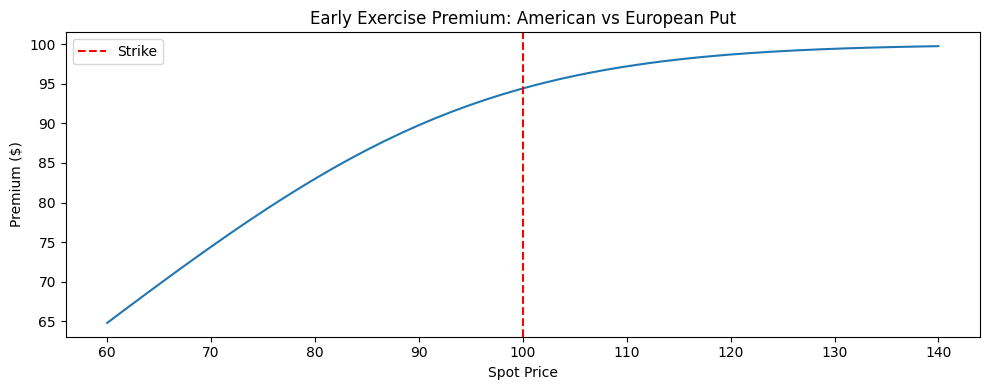

In [6]:
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.20
N = 500

euro_put = binomial_tree(S, K, T, r, sigma, N, 'put', american=False)
amer_put = binomial_tree(S, K, T, r, sigma, N, 'put', american=True)
early_exercise_premium = amer_put - euro_put

print(f"European put: {euro_put:.4f}")
print(f"American put: {amer_put:.4f}")
print(f"Early exercise premium: {early_exercise_premium:.4f}")

# Now vary spot price and plot the premium across moneyness
spots = np.linspace(60, 140, 100)
premiums = []
for s in spots:
    ep = binomial_tree(s, K, T, r, sigma, N, 'put', american=False)
    ap = binomial_tree(s, K, T, r, sigma, N, 'put', american=True)
    premiums.append(ap - ep)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(spots, premiums)
plt.axvline(K, color='red', linestyle='--', label='Strike')
plt.title("Early Exercise Premium: American vs European Put")
plt.xlabel("Spot Price")
plt.ylabel("Premium ($)")
plt.legend()
plt.tight_layout()
plt.show()